<a href="https://colab.research.google.com/github/MerciaMizoguchi/Tech-Challenge-FIAP/blob/main/Analise_Exploratoria-%20Mercia%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WineQT.csv')


Analise Exploratória dos Dados

In [72]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [74]:
df.shape

(1143, 13)

In [75]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


Tratamento dos Dados

In [79]:
#criar uma coluna no df para informar se o vinho é de alta qualidade > = 7, baixa/media qualidade < 7

import numpy as np

df['alta_qualidade'] = df['quality'] >= 7

df.head ()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,alta_qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,False


## Insight

# Como as características dos vinhos estão distribuidas entre eles.

*A análise das distribuições é essencial para identificar a necessidade de normalização, transformação de variáveis e tratamento de valores extremos antes da modelagem.*

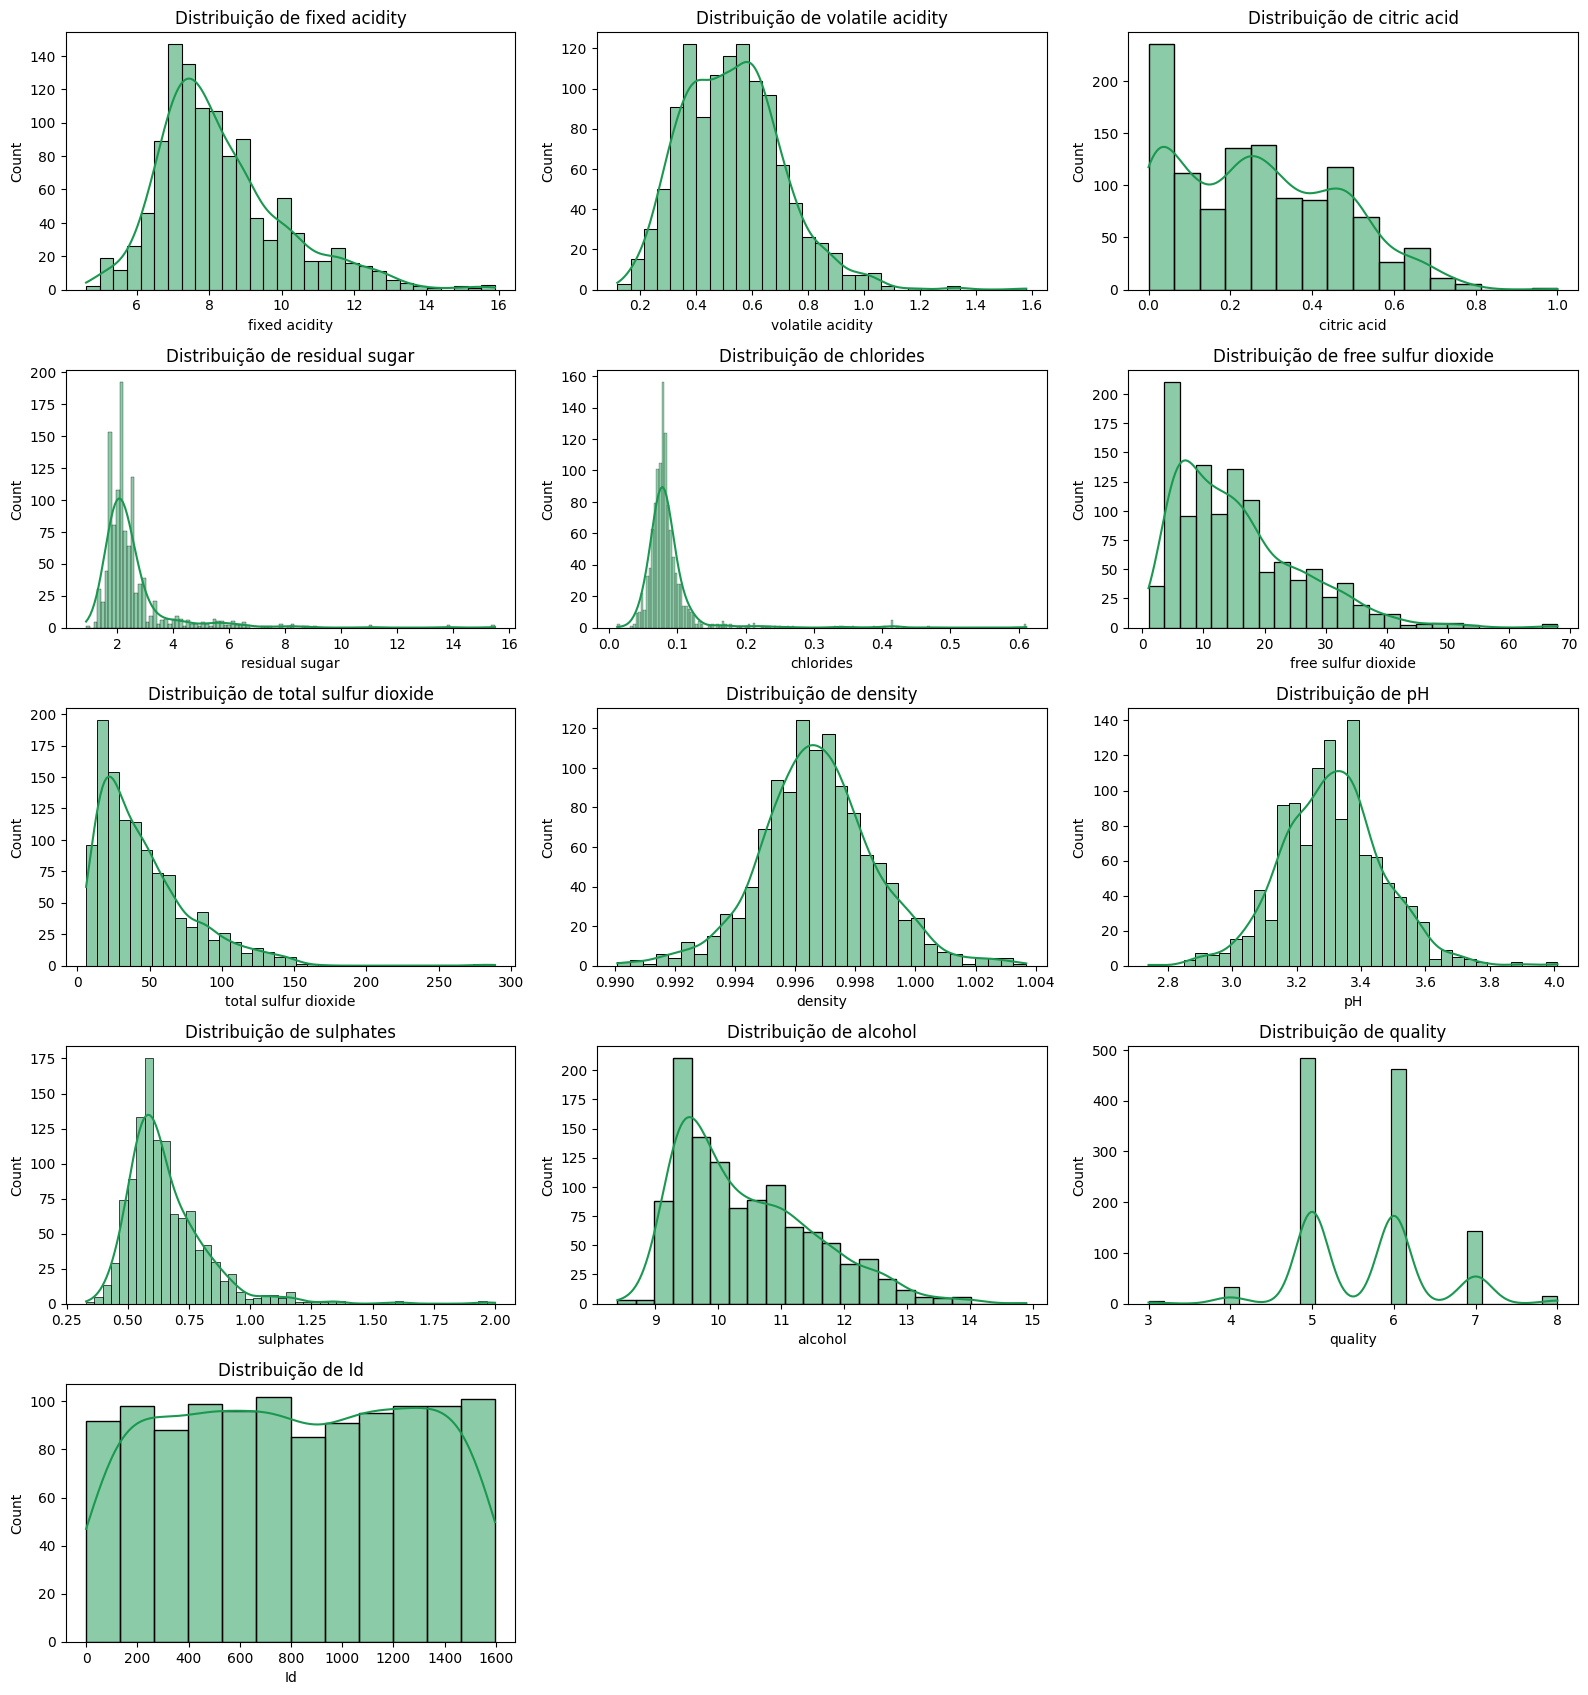

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["float64", "int64"]).columns

plt.figure(figsize=(16, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df[col], kde=True, color="#1a9850")
    plt.title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()


**Resultado**

Alcohol apresenta distribuição assimétrica à direita, indicando que a maioria dos vinhos possui teor alcoólico moderado, com poucos valores muito altos.

Volatile acidity possui cauda longa à direita, sugerindo que alguns vinhos apresentam níveis elevados de acidez volátil, característica associada a defeitos sensoriais.

Residual sugar apresenta distribuição altamente assimétrica, com valores extremos que podem influenciar a densidade do vinho.

Density, chlorides e sulfur dioxide também apresentam assimetrias e valores extremos, comuns em processos de vinificação.

# Quais características influenciam mais na qualidade do vinho?

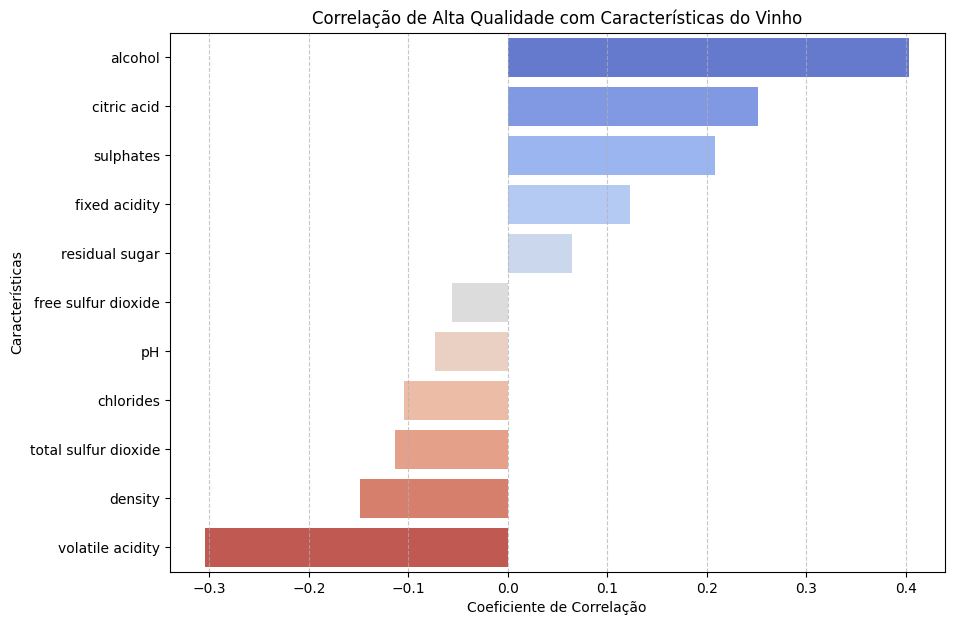

In [81]:
# Excluir a coluna 'quality' e 'Id' (se existir)
df_caracteristicas = df.drop(columns=['quality', 'Id'], errors='ignore')

matriz = df_caracteristicas.corr()

# Extrair a série de correlações da coluna 'alta_qualidade'
correlacao = matriz['alta_qualidade']

# Excluir a própria correlação de 'alta_qualidade_encoded' consigo mesma
# e as colunas 'quality' e 'Id' se estiverem presentes
correlacao = correlacao.drop(labels=['quality', 'alta_qualidade'], errors='ignore')

# Ordenar para melhor visualização
correlacao = correlacao.sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=correlacao.values, y=correlacao.index, palette='coolwarm', hue=correlacao.index, legend=False)
plt.title('Correlação de Alta Qualidade com Características do Vinho')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Características')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Resultado**

Identificado que as características mais importantes para definir a qualidade de um vinho são:
Alcohol, Citric acid e Volatile acidity

In [82]:
df_melhores_vinhos = df.sort_values(by='quality', ascending=False).head(10)
df_melhores_vinhos

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,alta_qualidade
1104,7.4,0.36,0.30,1.8,0.074,17.0,24.0,0.99419,3.24,0.70,11.4,8,1549,True
321,11.3,0.62,0.67,5.2,0.086,6.0,19.0,0.99880,3.22,0.69,13.4,8,455,True
340,9.4,0.30,0.56,2.8,0.080,6.0,17.0,0.99640,3.15,0.92,11.7,8,481,True
310,12.6,0.31,0.72,2.2,0.072,6.0,29.0,0.99870,2.88,0.82,9.8,8,440,True
850,8.6,0.42,0.39,1.8,0.068,6.0,12.0,0.99516,3.35,0.69,11.7,8,1202,True
271,5.6,0.85,0.05,1.4,0.045,12.0,88.0,0.99240,3.56,0.82,12.9,8,390,True
190,7.9,0.35,0.46,3.6,0.078,15.0,37.0,0.99730,3.35,0.86,12.8,8,267,True
197,10.3,0.32,0.45,6.4,0.073,5.0,13.0,0.99760,3.23,0.82,12.6,8,278,True
349,10.7,0.35,0.53,2.6,0.070,5.0,16.0,0.99720,3.15,0.65,11.0,8,495,True
769,10.0,0.26,0.54,1.9,0.083,42.0,74.0,0.99451,2.98,0.63,11.8,8,1090,True


# Distribuição de valores de cada característica mais relevante para a qualidade do vinho  

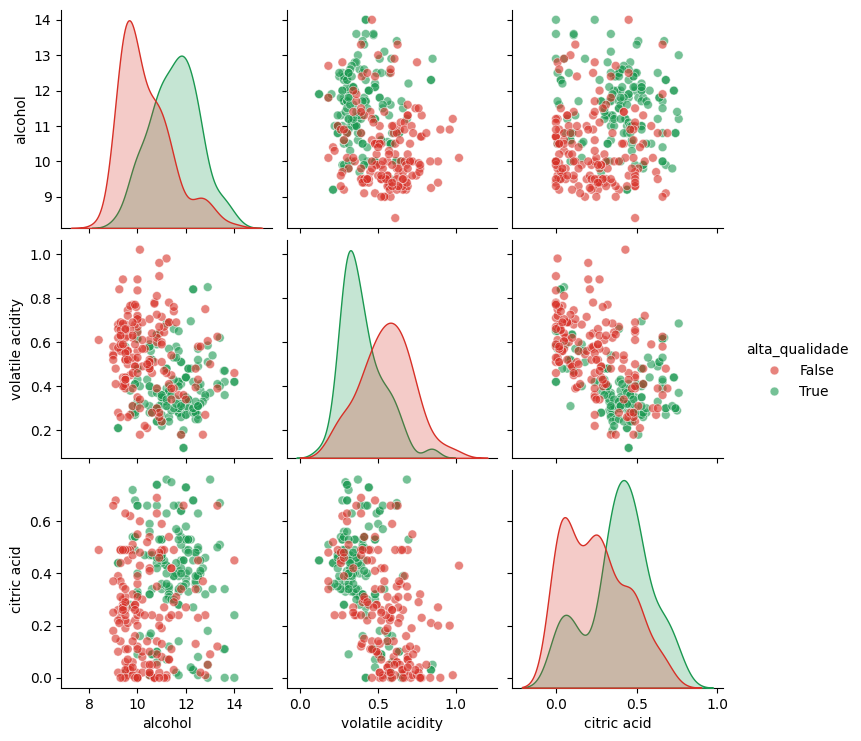

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
# separando as classes
df_true = df[df['alta_qualidade'] == True]
df_false = df[df['alta_qualidade'] == False]

# balanceando pelo menor grupo
min_size = min(len(df_true), len(df_false))

df_true_bal = df_true.sample(min_size, random_state=42)
df_false_bal = df_false.sample(min_size, random_state=42)

# dataset balanceado
df_bal = pd.concat([df_true_bal, df_false_bal])

vars_chave = ["alcohol", "volatile acidity","citric acid"]
palette = {
    False: "#d73027",  # vermelho forte
    True:  "#1a9850"   # verde forte
}

sns.pairplot(
    df_bal[vars_chave + ["alta_qualidade"]],
    hue="alta_qualidade",
    palette=palette,
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 40},
    diag_kws={"fill": True}
)

plt.show()




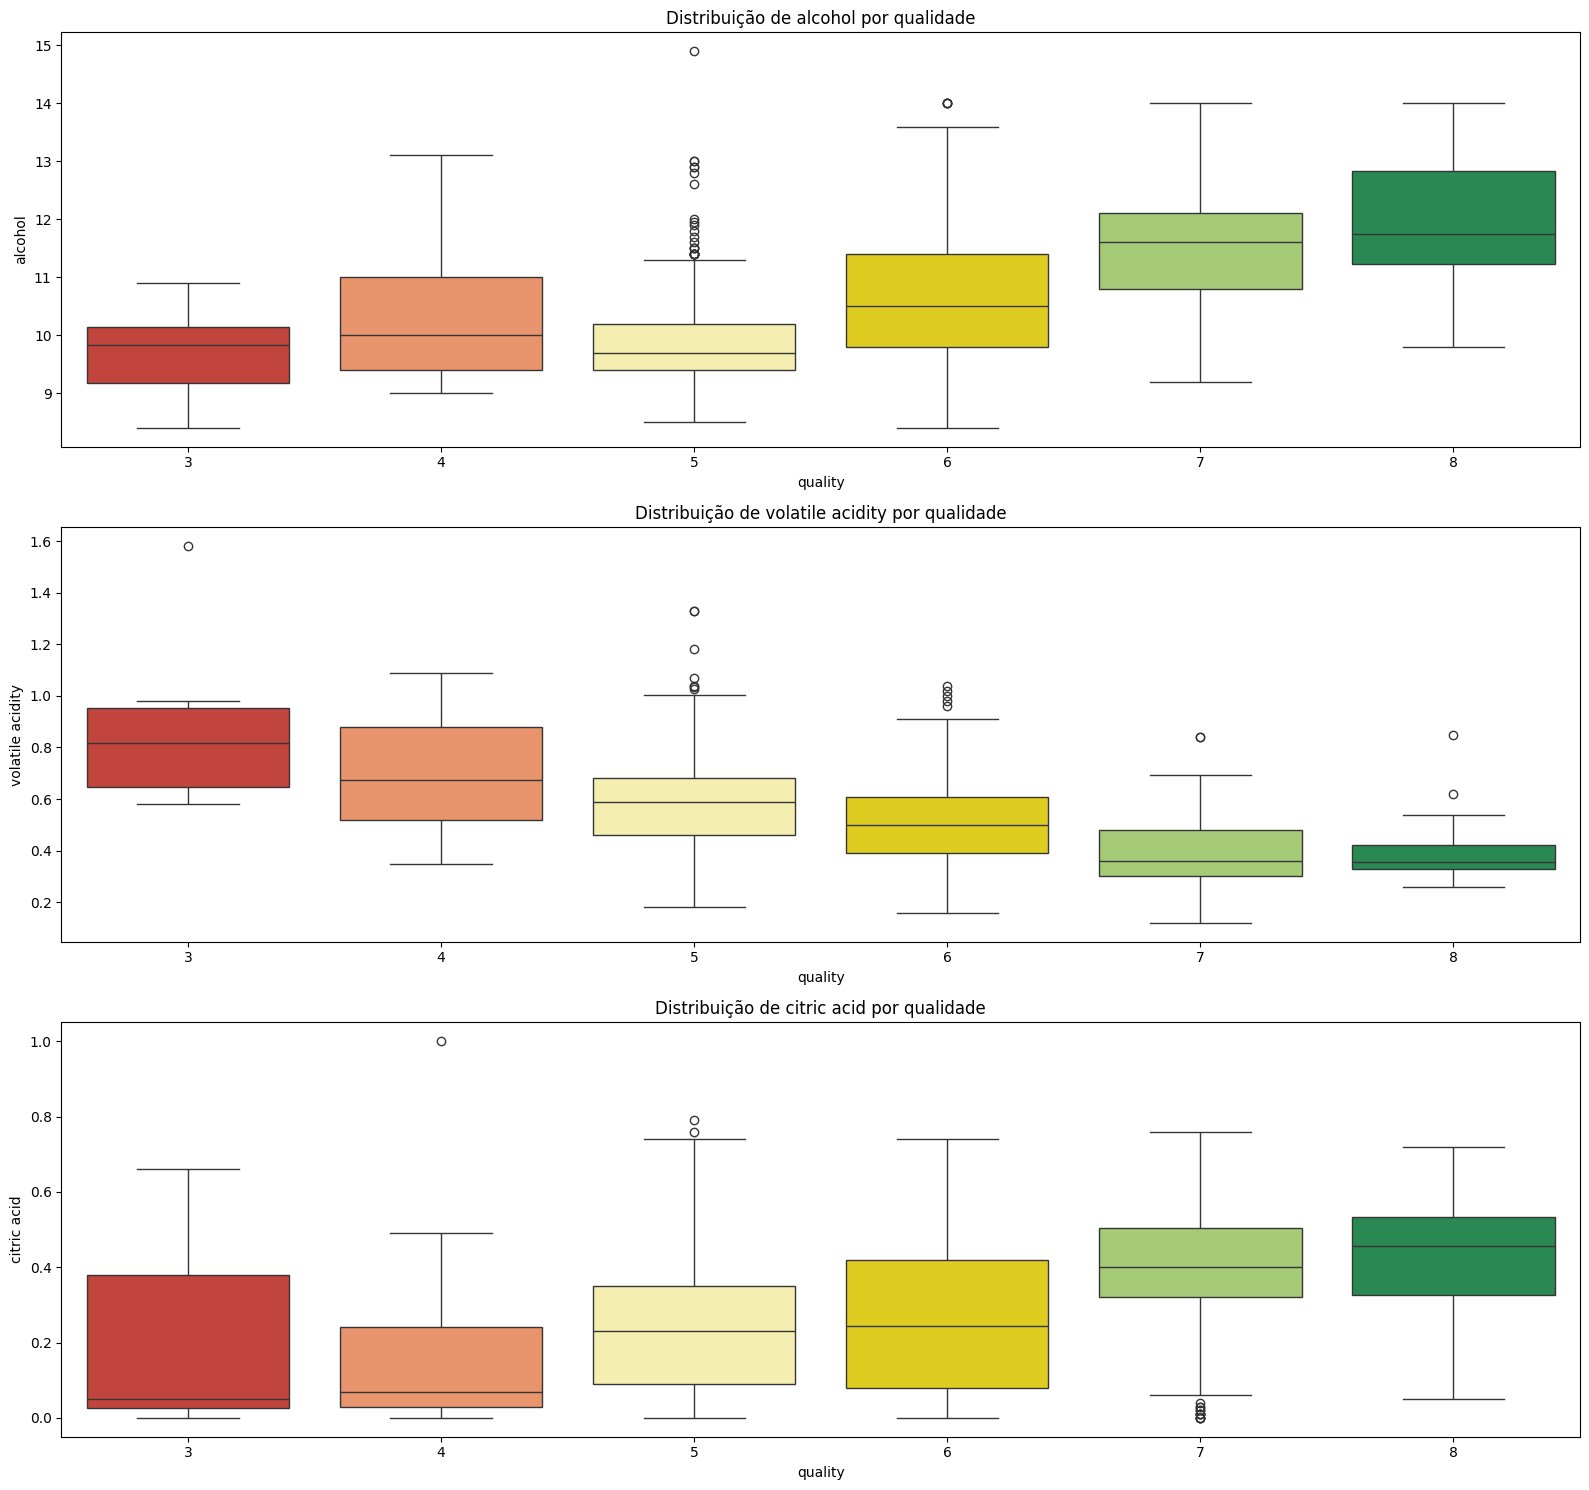

In [85]:
import seaborn as sns

# degradê contínuo só para os amarelos (quality 5 e 6)
amarelos = sns.color_palette(["#fff9a6", "#ffe600"], n_colors=2)

# definindo manualmente as cores desejadas
palette = {
    3: "#d73027",   # vermelho forte
    4: "#fc8d59",   # vermelho claro
    5: amarelos[0], # amarelo claro (degradê)
    6: amarelos[1], # amarelo forte (degradê)
    7: "#a6d96a",   # verde claro
    8: "#1a9850"    # verde forte
}

# lista de colunas numéricas (exceto quality)
colunas = ['alcohol', 'volatile acidity', 'citric acid']

plt.figure(figsize=(16, len(colunas) * 5)) # Adjust figure size based on number of columns

for i, coluna in enumerate(colunas, 1):
    plt.subplot(len(colunas), 1, i)
    sns.boxplot(data=df,x='quality',y=coluna,hue='quality',palette=palette,legend=False
)

    plt.title(f'Distribuição de {coluna} por qualidade')
    plt.tight_layout()

plt.show()

# Quais características possuem mais variancia na base de vinhos e quais possuem mais correlação entre si.

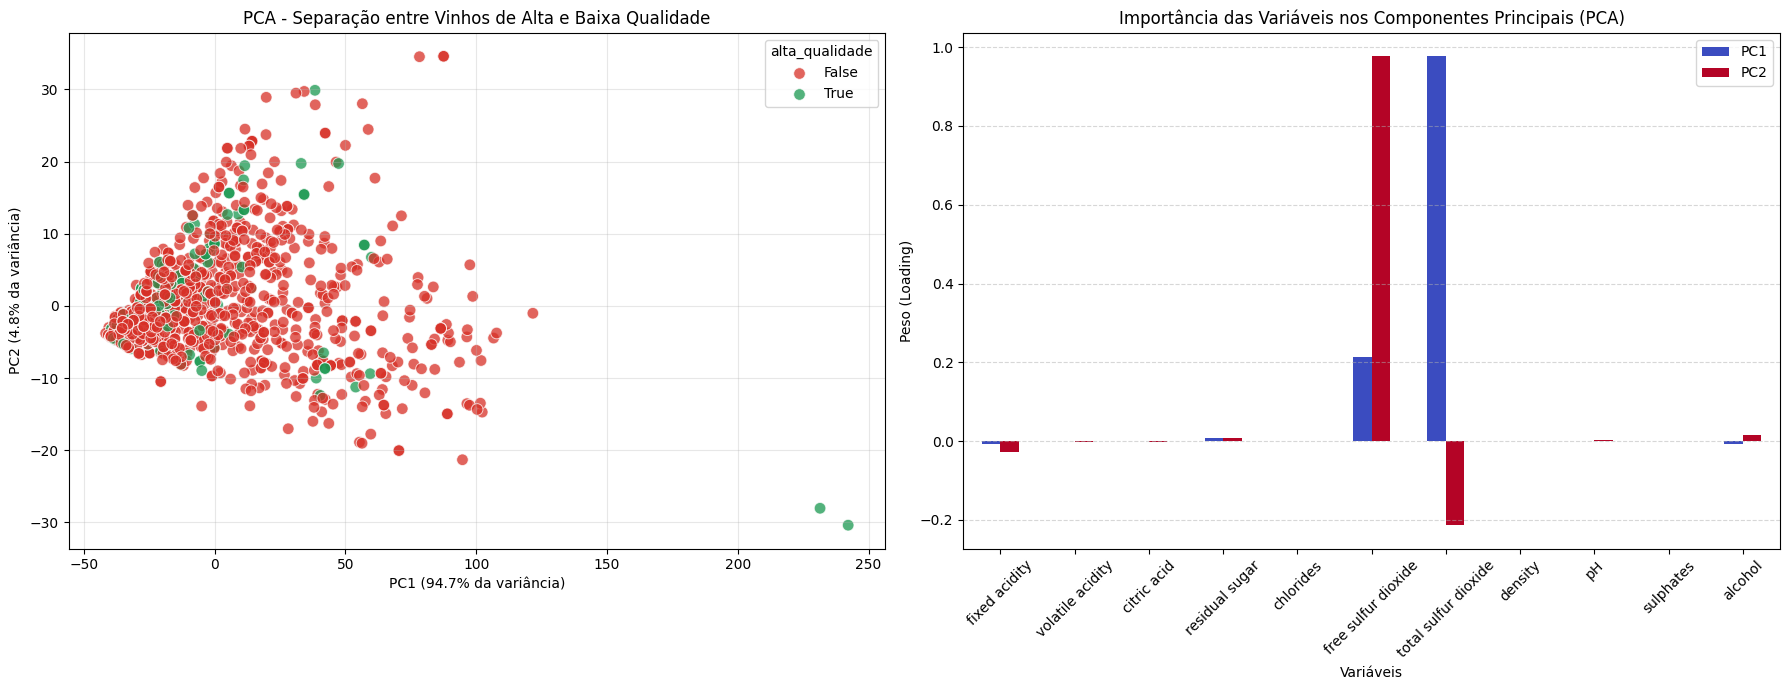

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Selecionar apenas variáveis numéricas (exceto a coluna alvo)
X = df.drop(columns=["alta_qualidade", "quality", "Id"], errors="ignore")
X = X.select_dtypes(include=["float64", "int64"])

# Variável alvo
y = df["alta_qualidade"]

# PCA com 2 componentes
pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Loadings (contribuição das variáveis)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

# Criar figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -----------------------------
# GRÁFICO 1 — PCA
# -----------------------------
palette = {False: "#d73027", True: "#1a9850"}

sns.scatterplot(
    x=components[:, 0],
    y=components[:, 1],
    hue=y,
    palette=palette,
    s=70,
    alpha=0.75,
    ax=axes[0]
)

axes[0].set_title("PCA - Separação entre Vinhos de Alta e Baixa Qualidade")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)")
axes[0].grid(alpha=0.3)

# -----------------------------
# GRÁFICO 2 — Importância das Variáveis
# -----------------------------
loadings.plot(kind="bar", ax=axes[1], colormap="coolwarm")
axes[1].set_title("Importância das Características nos Componentes Principais (PCA)")
axes[1].set_ylabel("Peso (Loading)")
axes[1].set_xlabel("Variáveis")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
